In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE




In [4]:
# =========================
# 1. Load Dataset
# =========================

print("Loading dataset...")

df = pd.read_csv("paySim.csv")

print("\nDataset Loaded Successfully")
print("Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# =========================
# 2. Check Missing Values
# =========================

print("\nMissing Values:")
print(df.isnull().sum())





Loading dataset...

Dataset Loaded Successfully
Shape: (6362620, 11)

First 5 Rows:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

Missing Values:
step


Fraud Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


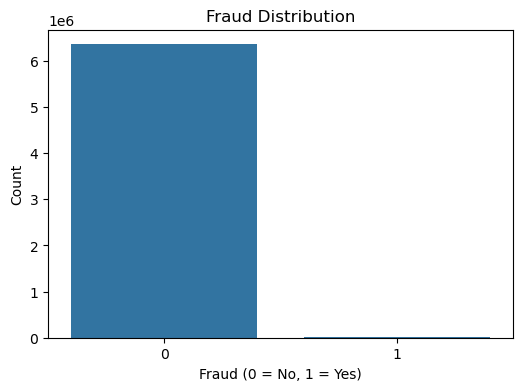

In [5]:

# =========================
# 3. Class Distribution
# =========================

print("\nFraud Distribution:")
print(df['isFraud'].value_counts())

print("\nFraud Percentage:")
print(df['isFraud'].value_counts(normalize=True) * 100)


# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df)
plt.title("Fraud Distribution")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


# =========================
# 4. Drop Unnecessary Columns
# =========================

df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)


# =========================
# 5. Feature Engineering
# =========================

df['balanceDiffOrig'] = (
    df['oldbalanceOrg'] - df['newbalanceOrig']
)

df['balanceDiffDest'] = (
    df['newbalanceDest'] - df['oldbalanceDest']
)



In [6]:

# =========================
# 6. Encode Transaction Type
# =========================

print("\nTransaction Types:")
print(df['type'].unique())

le = LabelEncoder()

df['type'] = le.fit_transform(df['type'])

print("\nEncoding Mapping:")

for i, label in enumerate(le.classes_):
    print(f"{label} --> {i}")




Transaction Types:
['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']

Encoding Mapping:
CASH_IN --> 0
CASH_OUT --> 1
DEBIT --> 2
PAYMENT --> 3
TRANSFER --> 4


In [7]:

# =========================
# 7. Separate Features and Target
# =========================

X = df.drop('isFraud', axis=1)

y = df['isFraud']



In [8]:

# =========================
# 8. Train Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)





Train Shape: (5090096, 10)
Test Shape: (1272524, 10)


In [9]:
# =========================
# 9. Apply SMOTE
# =========================

print("\nBefore SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())





Before SMOTE:
isFraud
0    5083526
1       6570
Name: count, dtype: int64

After SMOTE:
isFraud
0    5083526
1    5083526
Name: count, dtype: int64


In [10]:
# =========================
# 10. Logistic Regression
# =========================

print("\n" + "=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_lr))



LOGISTIC REGRESSION

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98   1270881
           1       0.02      0.89      0.05      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.92      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524

Precision: 0.023184145647638914
Recall: 0.8928788800973828
ROC-AUC: 0.9723465268700174


In [11]:
# =========================
# 11. Random Forest
# =========================

print("\n" + "=" * 50)
print("RANDOM FOREST")
print("=" * 50)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))





RANDOM FOREST

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.74      0.97      0.84      1643

    accuracy                           1.00   1272524
   macro avg       0.87      0.98      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524

Precision: 0.7445119103222793
Recall: 0.9701765063907486
ROC-AUC: 0.9990128851735257


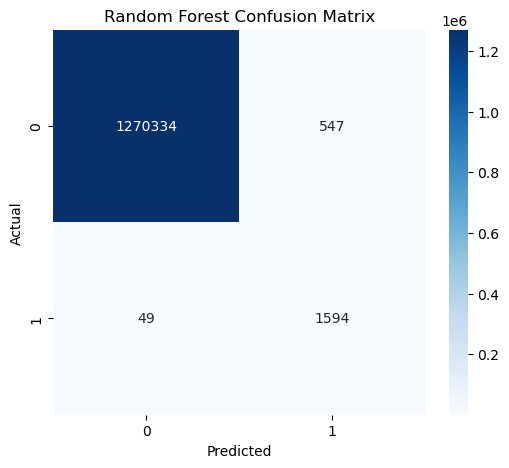

In [12]:
# =========================
# 12. Confusion Matrix
# =========================

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()




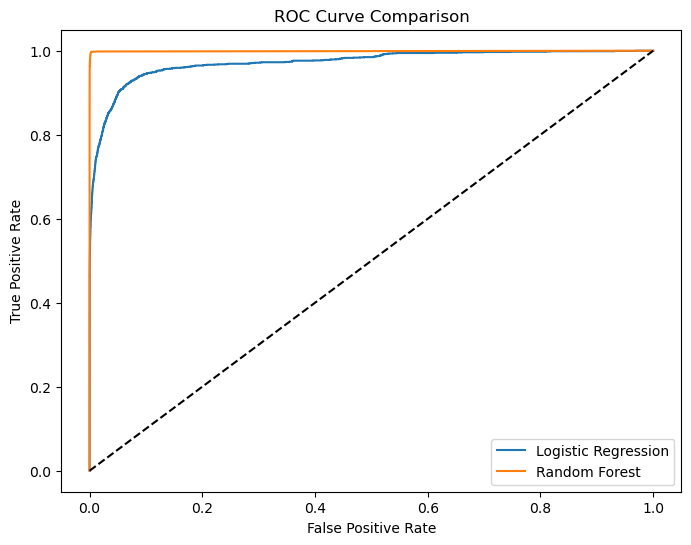

In [13]:
# =========================
# 13. ROC Curve
# =========================

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label='Logistic Regression'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label='Random Forest'
)

plt.plot(
    [0, 1],
    [0, 1],
    'k--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()




Top 10 Important Features:
           Feature  Importance
8  balanceDiffOrig    0.339336
3    oldbalanceOrg    0.182551
4   newbalanceOrig    0.137075
2           amount    0.097810
1             type    0.076193
9  balanceDiffDest    0.070810
0             step    0.043010
6   newbalanceDest    0.035208
5   oldbalanceDest    0.017185
7   isFlaggedFraud    0.000821


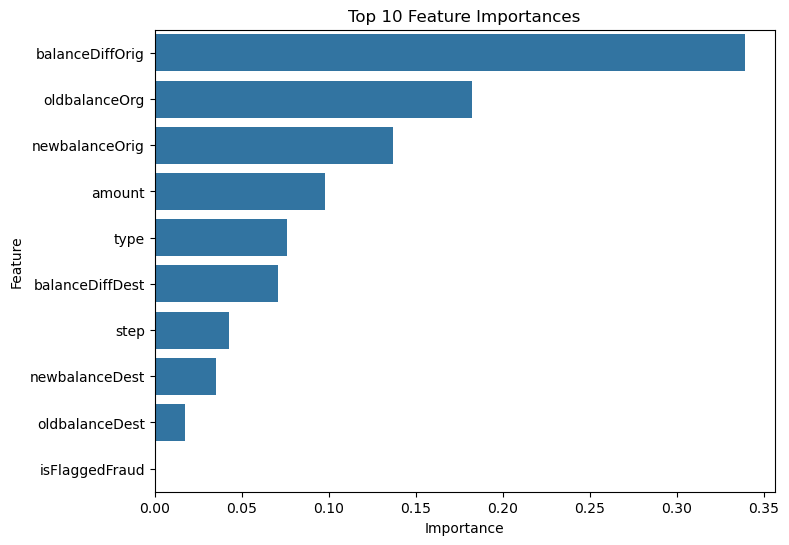

In [14]:

# =========================
# 14. Feature Importance
# =========================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Important Features:")

print(importance.head(10))


# Plot Feature Importance
plt.figure(figsize=(8, 6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importances")

plt.show()



In [17]:

# =========================
# 15. Final Comparison
# =========================

comparison = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'ROC-AUC'],
    'Logistic Regression': [
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_prob_lr)
    ],
    'Random Forest': [
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print("\nModel Comparison:")
print(comparison)



Model Comparison:
      Metric  Logistic Regression  Random Forest
0  Precision             0.023184       0.744512
1     Recall             0.892879       0.970177
2    ROC-AUC             0.972347       0.999013
